# Segment Anything Model (SAM) 

In [1]:
from ultralytics import YOLO
import torch


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/users/mvsjober/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [2]:
from samgeo import SamGeo
from samgeo.text_sam import LangSAM

In [3]:
import rasterio
from rasterio.windows import from_bounds
from rasterio.plot import show
from samgeo import SamGeo
from samgeo.text_sam import LangSAM

In [4]:
# from rasterio.windows import from_bounds
vrt_path = "https://vm0160.kaj.pouta.csc.fi/mml/ortokuva/2022/ortokuva_2022_1m.vrt"
image_path = "image.tif"
# Use https://kartta.paikkatietoikkuna.fi/ with XY tool to select other point, use in order: E, N.
center_x, center_y = 387519, 6688251
xmin, ymin, xmax, ymax = center_x - 1000, center_y - 1000, center_x + 1000, center_y + 1000

In [5]:
with rasterio.open(vrt_path) as src:
    window=from_bounds(xmin, ymin, xmax, ymax, src.transform)
    vrt = src.read(window=window)
    profile = src.profile
    profile.update({
        "driver": 'GTiff',
        "width": vrt.shape[1],
        "height": vrt.shape[2],
        "transform": src.window_transform(window)
    })
    with rasterio.open(image_path, 'w', **profile) as i:
        i.write(vrt)

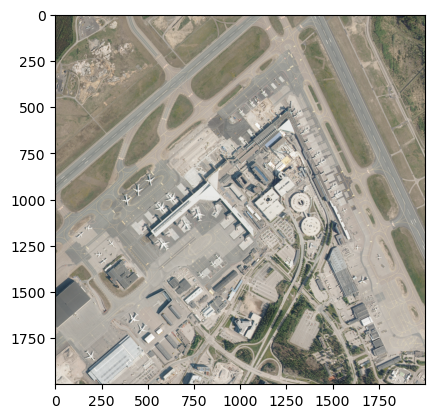

<Axes: >

In [6]:
show(vrt)

In [4]:
sam = SamGeo(
    model_type="vit_h",
    checkpoint="sam_vit_h_4b8939.pth",
    sam_kwargs=None,
    pred_iou_thresh=0.7,
)

In [ ]:
sam = SamGeo(
    model_type="vit_h",
    checkpoint="/projappl/project_462001167/models/sam_vit_h_4b8939.pth",
    sam_kwargs=None,
    pred_iou_thresh=0.7,
)

In [6]:
torch.save(sam, "/projappl/project_462001167/model.pth")

AttributeError: 'SamGeo' object has no attribute 'model'

In [ ]:
mask = 'segment.tif'
sam.generate(image_path, mask)

In [ ]:
sam.show_masks(cmap="binary_r")

In [ ]:
sam.show_anns(axis="off", alpha=1, output="annotations.tif")


In [ ]:
sam = LangSAM(model_type="sam2-hiera-base")

In [ ]:
text_prompt = "tree"

In [ ]:
sam.predict(image, text_prompt, box_threshold=0.24, text_threshold=0.24)